# 04 - Detekcija statističkih anomalija (outliera)

Ova sveska je prvi korak istraživačke analize, u njoj detektujemo
statistička odstupanja (outliere) u numeričkim kolonama.

Za to koristimo neparametarski pristup baziran na box-plotu i IQR
pravilu (Interquartile Range). Granice za outliere definišemo kao:
- Donja granica: `Q1 − 1.5 × IQR`
- Gornja granica: `Q3 + 1.5 × IQR`

Ovakav pristup biramo jer ne pretpostavlja normalnu raspodelu podataka,
radi na bilo kakvom obliku raspodele i pritom je intuitivno razumljiv.

Kao i do sada, sve analize u ovoj svesci radimo isključivo na trening
skupu (`X_train`), dok test skup ostaje netaknut do kraja projekta, radi
sprečavanja data leakage-a.

## 1. Učitavanje trening skupa

Umesto ponavljanja svih prethodnih koraka (učitavanje sirovog CSV-a,
konverzija, split), direktno učitavamo već pripremljen trening skup
iz foldera `data/processed/`


In [1]:
# Uvozimo osnovne biblioteke.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# seaborn je nadgradnja matplotlib-a — daje lepše grafike sa manje koda.
import seaborn as sns

# Podešavanja za prikaz.
pd.set_option("display.max_columns", None)

# Podešavanje stila za seaborn grafike — beli background sa mrežom.
sns.set_style("whitegrid")

# Podrazumevana veličina grafika (širina, visina u inčima).
plt.rcParams["figure.figsize"] = (10, 6)

# Učitavamo trening skup atributa (X_train) iz prethodne sveske.
X_train = pd.read_csv("../data/processed/X_train.csv")

print(f"Trening skup učitan: {X_train.shape[0]} redova × {X_train.shape[1]} kolona")

Trening skup učitan: 5625 redova × 19 kolona


## 2. Identifikacija numeričkih kolona za analizu

Box-plot i IQR pravilo primenjujemo samo na numeričke kolone. U našem
skupu to su:

- `tenure`
- `MonthlyCharges`
- `TotalCharges`

Kolonu `SeniorCitizen` ne uključujemo, iako je zapisana kao broj (0/1),
jer je konceptualno binarna kategorija, a box-plot na binarnoj vrednosti
nema mnogo smisla, dobili bismo samo dve tačke.

In [2]:
# Definišemo listu numeričkih kolona koje analiziramo.
numericke_kolone = ["tenure", "MonthlyCharges", "TotalCharges"]

# Osnovna statistika ovih kolona na trening skupu.
print("Osnovna statistika numeričkih kolona (trening skup):")
X_train[numericke_kolone].describe()

Osnovna statistika numeričkih kolona (trening skup):


,tenure,MonthlyCharges,TotalCharges
count,5625.000000,5625.000000,5625.000000
mean,32.562311,64.999316,2301.839520
std,24.542421,30.108642,2275.586084
min,1.000000,18.400000,18.800000
25%,9.000000,35.800000,413.000000
50%,29.000000,70.600000,1410.250000
75%,56.000000,90.050000,3801.700000
max,72.000000,118.650000,8684.800000


## 3. Analiza kolone `tenure`

`tenure` pokazuje koliko meseci je korisnik kod kompanije. Očekivane
vrednosti idu od 0 (novi korisnici) do 72 (najstariji, 6 godina).

Gledamo je kroz dva prikaza: box-plot, koji pokazuje kvartile, medijanu i
eventualne outliere, i histogram sa krivom, koji pokazuje oblik
raspodele same po sebi.

Posle vizuelne inspekcije, prebrojaćemo outliere i numerički, pomoću IQR
pravila (`Q1 − 1.5×IQR`, `Q3 + 1.5×IQR`).

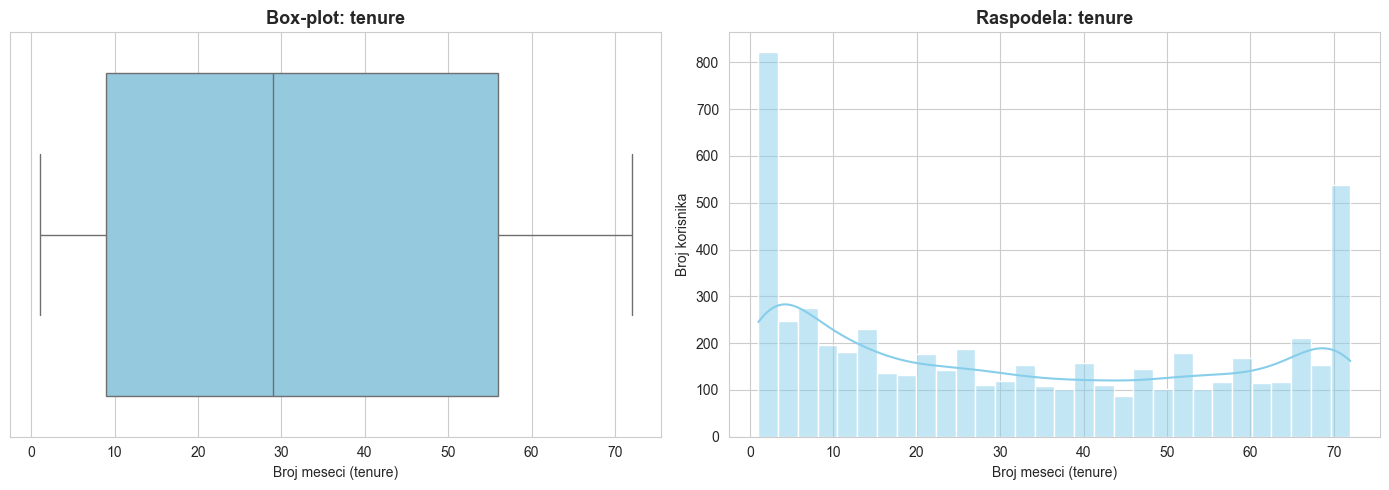

In [4]:
# Pravimo figuru sa dva grafika jedan pored drugog.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.boxplot(x=X_train["tenure"], ax=axes[0], color="skyblue")
axes[0].set_title("Box-plot: tenure", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Broj meseci (tenure)")



sns.histplot(X_train["tenure"], bins=30, kde=True, ax=axes[1], color="skyblue")
axes[1].set_title("Raspodela: tenure", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Broj meseci (tenure)")
axes[1].set_ylabel("Broj korisnika")


plt.tight_layout()

plt.savefig("../images/04_tenure_distribution.png", dpi=100, bbox_inches="tight")

plt.show()

### IQR računica za `tenure`

Sada isto proveravamo i numerički, računamo granice outliera po IQR
pravilu.

In [5]:
Q1 = X_train["tenure"].quantile(0.25)
Q3 = X_train["tenure"].quantile(0.75)
IQR = Q3 - Q1

# Granice za outliere.
donja_granica = Q1 - 1.5 * IQR
gornja_granica = Q3 + 1.5 * IQR

# Brojimo koliko vrednosti pada van granica.To cemo uraditi preko uslova i sa funkcijom sum() cemo ih prebrojati.
outliers_mask = (X_train["tenure"] < donja_granica) | (X_train["tenure"] > gornja_granica)
broj_outliera = outliers_mask.sum()

# Ispisujemo rezultate.
print(f"Kolona: tenure")
print(f"  Q1 (25. percentil): {Q1:.2f}")
print(f"  Q3 (75. percentil): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Donja granica (Q1 - 1.5*IQR): {donja_granica:.2f}")
print(f"  Gornja granica (Q3 + 1.5*IQR): {gornja_granica:.2f}")
print(f"  Broj outliera: {broj_outliera} ({100*broj_outliera/len(X_train):.2f}%)")

Kolona: tenure
  Q1 (25. percentil): 9.00
  Q3 (75. percentil): 56.00
  IQR: 47.00
  Donja granica (Q1 - 1.5*IQR): -61.50
  Gornja granica (Q3 + 1.5*IQR): 126.50
  Broj outliera: 0 (0.00%)


### Tumačenje za `tenure`

Raspodela je bimodalna, ima dva izražena vrha: jedan na malim
vrednostima (oko 0-5 meseci), što su nove pretplate, i drugi na velikim
vrednostima (oko 70+ meseci), dugogodišnji korisnici. Ovo ima smisla i
sugeriše da postoje dve različite grupe korisnika, oni koji se brzo
odluče (ili ostanu ili odu), i oni koji su lojalni dugoročno.

Kad je reč o outlierima, prema IQR pravilu ih nema u koloni `tenure`.
Granice [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] izlaze izvan opsega stvarnih
vrednosti (min=0, max=72), pa nijedna vrednost ne pada van njih. Ovo je i
očekivano, `tenure` je prirodno ograničena kolona bez ekstremnih
vrednosti.

Iz ovoga možemo zaključiti da nema potrebe za uklanjanjem ili
transformacijom outliera u ovoj koloni.

## 4. Analiza kolone `MonthlyCharges`

`MonthlyCharges` pokazuje koliko korisnik plaća mesečno. Vrednosti
očekujemo u razumnom opsegu, od oko 18$ za osnovnu uslugu do oko 120$ za
najskuplji paket sa svim dodacima.

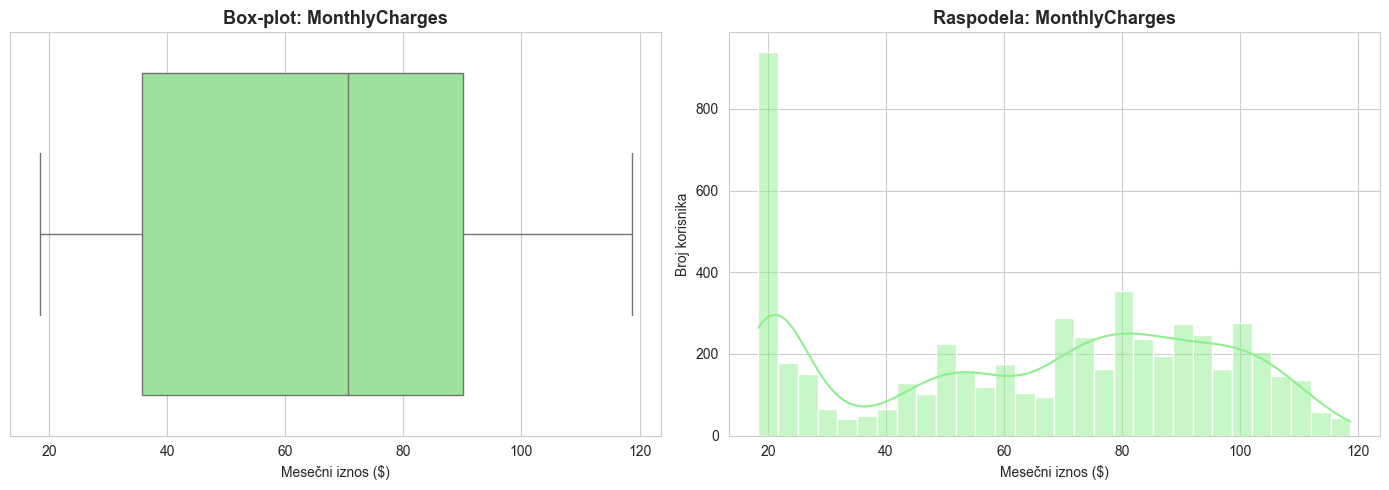

In [ ]:
# Ista struktura kao za tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-plot
sns.boxplot(x=X_train["MonthlyCharges"], ax=axes[0], color="lightgreen")
axes[0].set_title("Box-plot: MonthlyCharges", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mesečni iznos ($)")

# Histogram
sns.histplot(X_train["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Raspodela: MonthlyCharges", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mesečni iznos ($)")
axes[1].set_ylabel("Broj korisnika")

plt.tight_layout()
plt.savefig("../images/04_monthly_charges_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

In [7]:
# IQR računica za MonthlyCharges.
Q1 = X_train["MonthlyCharges"].quantile(0.25)
Q3 = X_train["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1

donja_granica = Q1 - 1.5 * IQR
gornja_granica = Q3 + 1.5 * IQR

outliers_mask = (X_train["MonthlyCharges"] < donja_granica) | (X_train["MonthlyCharges"] > gornja_granica)
broj_outliera = outliers_mask.sum()

print(f"Kolona: MonthlyCharges")
print(f"  Q1 (25. percentil): {Q1:.2f}")
print(f"  Q3 (75. percentil): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Donja granica (Q1 - 1.5*IQR): {donja_granica:.2f}")
print(f"  Gornja granica (Q3 + 1.5*IQR): {gornja_granica:.2f}")
print(f"  Broj outliera: {broj_outliera} ({100*broj_outliera/len(X_train):.2f}%)")

Kolona: MonthlyCharges
  Q1 (25. percentil): 35.80
  Q3 (75. percentil): 90.05
  IQR: 54.25
  Donja granica (Q1 - 1.5*IQR): -45.58
  Gornja granica (Q3 + 1.5*IQR): 171.43
  Broj outliera: 0 (0.00%)


### Tumačenje za `MonthlyCharges`

Raspodela je višemodalna, vidi se nekoliko izraženih vrhova koji
odgovaraju različitim tipovima paketa: osnovni telefonski paket oko 20$,
srednji paketi oko 70-80$, i kompletni paketi sa svim dodacima ka 100$+.
Primetno je da je najjeftiniji paket od 20$ znatno dominantniji u odnosu
na ostale tipove.

Prema IQR pravilu, nema outliera ni u ovoj koloni, sve vrednosti padaju
unutar granica [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. Ovo je i očekivano, jer su
cene paketa ograničene poslovnom logikom, postoji jasan minimum i
maksimum onoga što korisnik može mesečno da plati.

Ni ovde, dakle, nema potrebe za uklanjanjem ili transformacijom.

## 5. Analiza kolone `TotalCharges`

`TotalCharges` pokazuje ukupan iznos koji je korisnik platio od početka
korišćenja usluge. Za razliku od `MonthlyCharges`, ova kolona je
kumulativna, odnosno što je korisnik duže kod kompanije, to joj je
vrednost veća.

Zbog te kumulativne prirode, očekujemo desno iskošenu raspodelu: mnogo
korisnika sa malim `TotalCharges` (novi korisnici ili oni sa manjim
paketima), i manje njih sa velikim vrednostima (dugogodišnji korisnici sa
skupljim paketima).

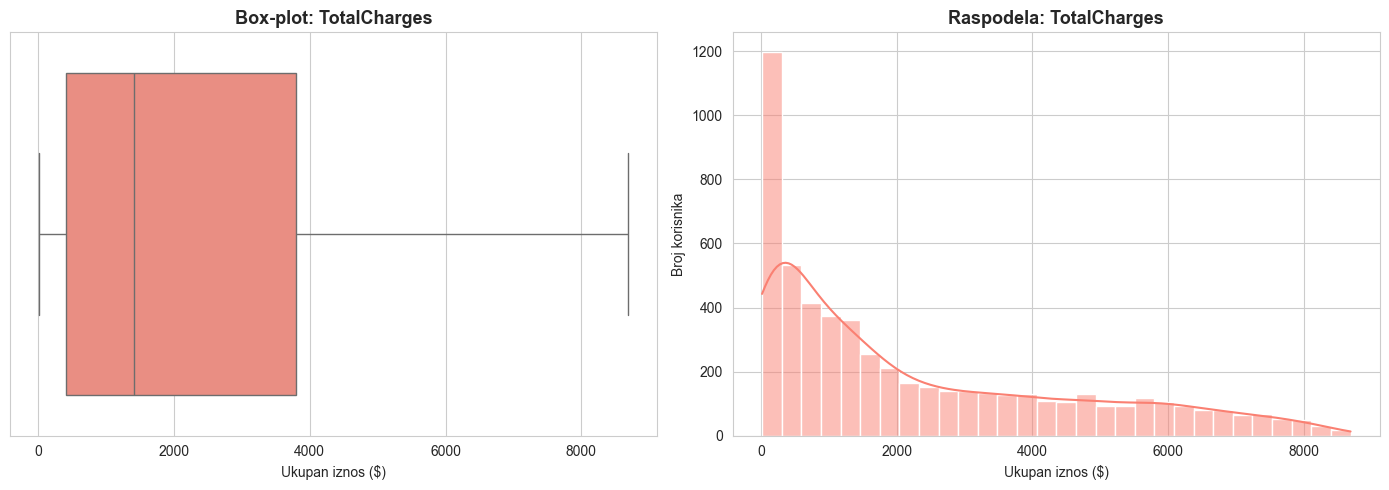

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-plot
sns.boxplot(x=X_train["TotalCharges"], ax=axes[0], color="salmon")
axes[0].set_title("Box-plot: TotalCharges", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Ukupan iznos ($)")

# Histogram
sns.histplot(X_train["TotalCharges"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Raspodela: TotalCharges", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Ukupan iznos ($)")
axes[1].set_ylabel("Broj korisnika")

plt.tight_layout()
plt.savefig("../images/04_total_charges_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

In [9]:
# IQR računica za TotalCharges.
Q1 = X_train["TotalCharges"].quantile(0.25)
Q3 = X_train["TotalCharges"].quantile(0.75)
IQR = Q3 - Q1

donja_granica = Q1 - 1.5 * IQR
gornja_granica = Q3 + 1.5 * IQR

outliers_mask = (X_train["TotalCharges"] < donja_granica) | (X_train["TotalCharges"] > gornja_granica)
broj_outliera = outliers_mask.sum()

print(f"Kolona: TotalCharges")
print(f"  Q1 (25. percentil): {Q1:.2f}")
print(f"  Q3 (75. percentil): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Donja granica (Q1 - 1.5*IQR): {donja_granica:.2f}")
print(f"  Gornja granica (Q3 + 1.5*IQR): {gornja_granica:.2f}")
print(f"  Broj outliera: {broj_outliera} ({100*broj_outliera/len(X_train):.2f}%)")

Kolona: TotalCharges
  Q1 (25. percentil): 413.00
  Q3 (75. percentil): 3801.70
  IQR: 3388.70
  Donja granica (Q1 - 1.5*IQR): -4670.05
  Gornja granica (Q3 + 1.5*IQR): 8884.75
  Broj outliera: 0 (0.00%)


### Tumačenje za `TotalCharges`

Raspodela je desno iskošena, kako smo i očekivali zbog kumulativne
prirode kolone. Većina korisnika ima male vrednosti (novi korisnici ili
oni sa nižim paketima), a broj korisnika sa visokim vrednostima postepeno
opada.

Prema IQR pravilu, nema formalnih outliera, sve vrednosti padaju unutar
granica. Iako raspodela ima dugačak rep udesno, IQR pravilo ga toleriše
zbog samog rasporeda kvartila.

Vredi napomenuti da bi ova iskošenost mogla biti relevantna za neke
modele, posebno linearne, koji pretpostavljaju normalnost. Kasnije,
prilikom pripreme podataka, razmotrićemo eventualnu log-transformaciju
kolone `TotalCharges` kao način da se iskošenost smanji.

Kao i kod prethodne dve kolone, nema potrebe za uklanjanjem outliera,
transformacija oblika ostaje moguća opcija za kasnije.

---

## 6. Zaključak

Detekcija anomalija na trening skupu pokazuje da je skup statistički
čist:

| Kolona | Q1 | Q3 | IQR | Broj outliera |
|---|---|---|---|---|
| `tenure` | 9.00 | 56.00 | 47.00 | 0 |
| `MonthlyCharges` | 35.80 | 90.05 | 54.25 | 0 |
| `TotalCharges` | 413.00 | 3801.70 | 3388.70 | 0 |

Prema IQR pravilu, nijedna od tri numeričke kolone ne sadrži outliere.
`tenure` ima bimodalnu raspodelu, sa dva vrha koja odgovaraju novim i
dugogodišnjim korisnicima, `MonthlyCharges` je višemodalna i odražava
strukturu paketa (osnovni, srednji, kompletni), dok je `TotalCharges`
desno iskošena zbog svoje kumulativne prirode.

Za sada ne uklanjamo nijedan podatak, jer su sve vrednosti legitimne.
Jedino što ostavljamo kao mogućnost za kasnije je log-transformacija
kolone `TotalCharges`, radi smanjenja iskošenosti.